# 05 — Two-lane mixed traffic (heterogeneous)

Slow (`v_max=2`) and fast (`v_max=5`) vehicles share two lanes. How does the slow-vehicle fraction `f_slow` degrade throughput, and how much does lane-changing (`p_chg`) recover? After the sweep, space-time diagrams show the per-vehicle structure of the flow.

**Cache convention** — per-seed shape preserved so SD bands can be regenerated without resimulating.

In [1]:
%load_ext autoreload
%autoreload 2

import os, time, numpy as np, matplotlib.pyplot as plt
from tqdm.auto import tqdm

from nasch_two_lane import TwoLaneNaSch, TwoLaneNaSchWithLights
from nasch_two_lane_viz import (
    record_space_time, plot_space_time_velocity,
    plot_space_time_identity, plot_space_time_type, find_lane_changers,
)

plt.rcParams.update({
    'figure.figsize': (8, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
})

DATA_DIR = '../data'
FIGURES_DIR = '../figures'
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# ─── Global parameters ────────────────────────────────────────────
L          = 500
V_MAX      = 5
V_SLOW     = 2
V_FAST     = 5
P_RAND     = 0.3
P_IN       = 0.4
T_WARMUP   = 5000
T_MEASURE  = 10000
N_SEEDS    = 5
SEEDS      = np.arange(N_SEEDS)
V_FREE     = V_MAX - P_RAND

F_SLOW_GRID = np.array([0.0, 0.1, 0.2, 0.3, 0.5])
P_CHG_GRID  = np.array([0.0, 0.1, 0.3, 0.5, 1.0])

# Cache convention: per-seed shape preserved.

def load_or_compute(path, compute_fn, force=False):
    if force or not os.path.exists(path):
        result = compute_fn()
        np.savez(path, **result)
        return result
    with np.load(path) as f:
        return {k: f[k] for k in f.files}

def greenwave_offsets(N, T_cycle, v_free=V_FREE, L_road=L):
    s = L_road / (N + 1)
    return np.array([int(round((i * s / v_free) % T_cycle))
                     for i in range(N)])


Failed to read module file 'C:\Users\Bakri\AppData\Local\Programs\Python\Python311\Lib\functools.py' for module 'functools': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\Bakri\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bakri\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bakri\AppData\Local\Programs\Python\Python311\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load
  File "<frozen importlib._

Failed to read module file 'C:\Users\Bakri\AppData\Local\Programs\Python\Python311\Lib\pydoc_data\topics.py' for module 'pydoc_data.topics': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\Bakri\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bakri\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bakri\AppData\Local\Programs\Python\Python311\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load
  File "<fr

Failed to read module file 'C:\Users\Bakri\AppData\Local\Programs\Python\Python311\Lib\re\_casefix.py' for module 're._casefix': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\Bakri\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bakri\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bakri\AppData\Local\Programs\Python\Python311\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load
  File "<frozen importl

Failed to read module file 'C:\Users\Bakri\AppData\Local\Programs\Python\Python311\Lib\shlex.py' for module 'shlex': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\Bakri\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bakri\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bakri\AppData\Local\Programs\Python\Python311\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load
  File "<frozen importlib._bootstra

Failed to read module file 'C:\Users\Bakri\AppData\Local\Programs\Python\Python311\Lib\urllib\parse.py' for module 'urllib.parse': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\Bakri\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bakri\AppData\Roaming\Python\Python311\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Bakri\AppData\Local\Programs\Python\Python311\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load
  File "<frozen impor

## Sweep — (f_slow, p_chg)

Open boundary, no lights. Per cell `(f, p)`, run `n_seeds=5` and record `J_total`, `v_mean_all/fast/slow`, `rho_lane_0/1`. Cache preserves per-seed shape `(5, 5, 5)` for each metric.

In [2]:
def per_step_metrics(sim, T_meas):
    """One full measurement window — accumulates per-type velocity
    sums and per-lane density samples."""
    sim.outflow_count = 0
    sum_v_all = 0.0
    n_v_all = 0
    sum_v_fast = 0.0
    n_v_fast = 0
    sum_v_slow = 0.0
    n_v_slow = 0
    rho0_acc = 0.0
    rho1_acc = 0.0
    for _ in range(T_meas):
        sim.step(record_flow=True)
        mask = sim.road >= 0
        if np.any(mask):
            sum_v_all += float(np.sum(sim.road[mask]))
            n_v_all += int(np.sum(mask))
            fast_mask = mask & (sim.v_max_arr == V_FAST)
            slow_mask = mask & (sim.v_max_arr == V_SLOW)
            sum_v_fast += float(np.sum(sim.road[fast_mask]))
            n_v_fast += int(np.sum(fast_mask))
            sum_v_slow += float(np.sum(sim.road[slow_mask]))
            n_v_slow += int(np.sum(slow_mask))
        rho0_acc += float(np.sum(sim.road[0] >= 0)) / sim.L
        rho1_acc += float(np.sum(sim.road[1] >= 0)) / sim.L
    return dict(
        J_total=sim.outflow_count / T_meas,
        v_mean_all=sum_v_all / max(n_v_all, 1),
        v_mean_fast=sum_v_fast / max(n_v_fast, 1),
        v_mean_slow=sum_v_slow / max(n_v_slow, 1),
        rho_lane_0=rho0_acc / T_meas,
        rho_lane_1=rho1_acc / T_meas,
    )

def compute_mixed_sweep():
    nf, nc, ns = len(F_SLOW_GRID), len(P_CHG_GRID), N_SEEDS
    metrics_keys = ('J_total', 'v_mean_all', 'v_mean_fast', 'v_mean_slow',
                    'rho_lane_0', 'rho_lane_1')
    out = {k: np.zeros((nf, nc, ns)) for k in metrics_keys}
    t0 = time.time()
    for fi, f_slow in enumerate(tqdm(F_SLOW_GRID, desc='f_slow')):
        for ci, p_chg in enumerate(P_CHG_GRID):
            for si, seed in enumerate(SEEDS):
                np.random.seed(int(seed))
                sim = TwoLaneNaSch(
                    L=L, n_lanes=2, v_max=V_MAX, p_rand=P_RAND,
                    p_chg=float(p_chg), boundary='open', p_in=P_IN,
                    v_max_slow=V_SLOW, v_max_fast=V_FAST,
                    f_slow=float(f_slow),
                )
                sim.warmup(T_WARMUP)
                m = per_step_metrics(sim, T_MEASURE)
                for k in metrics_keys:
                    out[k][fi, ci, si] = m[k]
    out.update(
        f_slow_grid=F_SLOW_GRID, p_chg_grid=P_CHG_GRID, seeds=SEEDS,
        v_max=V_MAX, v_slow=V_SLOW, v_fast=V_FAST, p_rand=P_RAND,
        p_in=P_IN, L=L, T_warmup=T_WARMUP, T_measure=T_MEASURE,
        wall_clock=time.time() - t0,
    )
    return out

S = load_or_compute(f'{DATA_DIR}/05_two_lane_mixed.npz', compute_mixed_sweep)
print(f'wall-clock: {float(S["wall_clock"]):.1f} s')


f_slow:   0%|          | 0/5 [00:00<?, ?it/s]

wall-clock: 1000.0 s


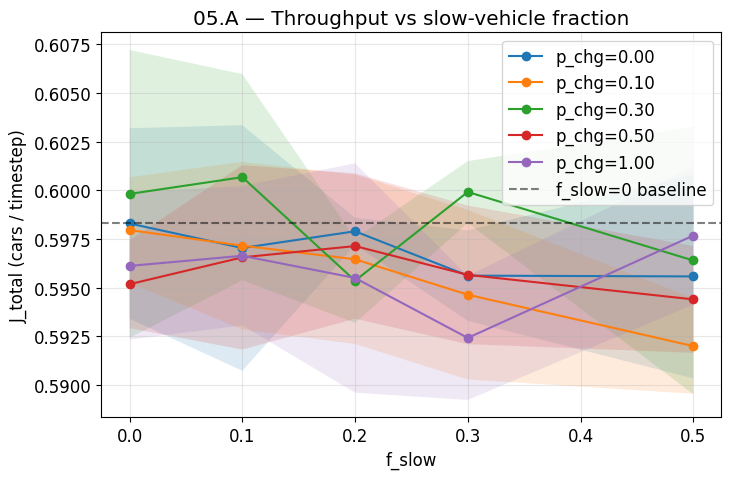

In [3]:
# Figure 05.A — J vs f_slow, one curve per p_chg.
fig, ax = plt.subplots()
for ci, p_chg in enumerate(P_CHG_GRID):
    m = S['J_total'][:, ci, :].mean(axis=-1)
    s = S['J_total'][:, ci, :].std(axis=-1)
    ax.plot(F_SLOW_GRID, m, '-o', label=f'p_chg={p_chg:.2f}')
    ax.fill_between(F_SLOW_GRID, m - s, m + s, alpha=0.15)
ax.axhline(S['J_total'][0, 0, :].mean(), color='k', linestyle='--',
            alpha=0.5, label='f_slow=0 baseline')
ax.set_xlabel('f_slow')
ax.set_ylabel('J_total (cars / timestep)')
ax.set_title('05.A — Throughput vs slow-vehicle fraction')
ax.legend()
fig.savefig(f'{FIGURES_DIR}/05_J_vs_fslow.png')
plt.show()


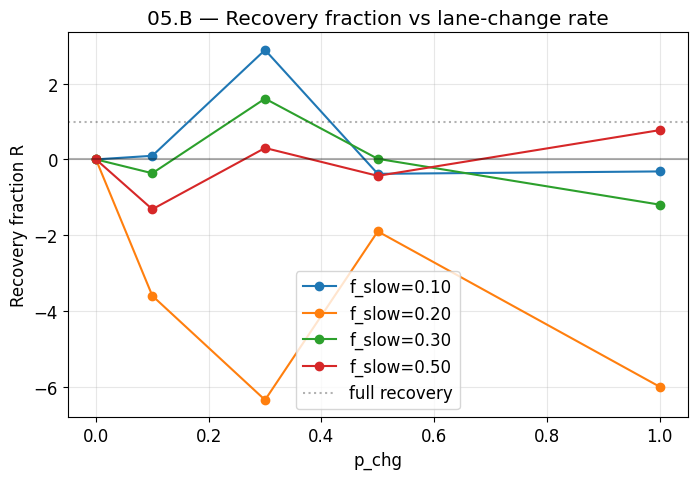

In [4]:
# Figure 05.B — Recovery fraction R(f, p) vs p_chg.
# R = (J(f, p) - J(f, 0)) / (J(0, ·) - J(f, 0))
# J(0, ·) is taken as the mean baseline at f_slow=0 (any p_chg works since
# lane-change is a no-op when both types are identical — pick p_chg=0).
J = S['J_total']
J_0 = J[0, 0, :].mean()  # f_slow=0, p_chg=0
fig, ax = plt.subplots()
for fi, f_slow in enumerate(F_SLOW_GRID):
    if f_slow == 0:
        continue
    J_f0 = J[fi, 0, :].mean()  # no lane-change baseline at this f_slow
    if J_0 - J_f0 < 1e-6:
        continue
    R = (J[fi, :, :].mean(axis=-1) - J_f0) / (J_0 - J_f0)
    ax.plot(P_CHG_GRID, R, '-o', label=f'f_slow={f_slow:.2f}')
ax.axhline(0, color='k', alpha=0.3)
ax.axhline(1, color='k', linestyle=':', alpha=0.3, label='full recovery')
ax.set_xlabel('p_chg')
ax.set_ylabel('Recovery fraction R')
ax.set_title('05.B — Recovery fraction vs lane-change rate')
ax.legend()
fig.savefig(f'{FIGURES_DIR}/05_recovery_fraction.png')
plt.show()


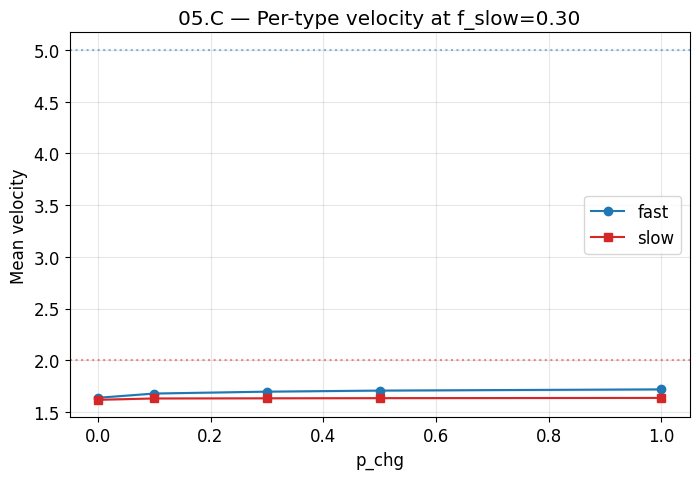

In [5]:
# Figure 05.C — v_mean_fast and v_mean_slow vs p_chg at f_slow=0.3.
fi = int(np.where(F_SLOW_GRID == 0.3)[0][0])
fig, ax = plt.subplots()
ax.plot(P_CHG_GRID, S['v_mean_fast'][fi].mean(axis=-1),
         '-o', color='C0', label='fast')
ax.plot(P_CHG_GRID, S['v_mean_slow'][fi].mean(axis=-1),
         '-s', color='C3', label='slow')
ax.fill_between(P_CHG_GRID,
                 S['v_mean_fast'][fi].mean(axis=-1) - S['v_mean_fast'][fi].std(axis=-1),
                 S['v_mean_fast'][fi].mean(axis=-1) + S['v_mean_fast'][fi].std(axis=-1),
                 alpha=0.15, color='C0')
ax.fill_between(P_CHG_GRID,
                 S['v_mean_slow'][fi].mean(axis=-1) - S['v_mean_slow'][fi].std(axis=-1),
                 S['v_mean_slow'][fi].mean(axis=-1) + S['v_mean_slow'][fi].std(axis=-1),
                 alpha=0.15, color='C3')
ax.axhline(V_FAST, color='C0', linestyle=':', alpha=0.5)
ax.axhline(V_SLOW, color='C3', linestyle=':', alpha=0.5)
ax.set_xlabel('p_chg')
ax.set_ylabel('Mean velocity')
ax.set_title(f'05.C — Per-type velocity at f_slow={F_SLOW_GRID[fi]:.2f}')
ax.legend()
fig.savefig(f'{FIGURES_DIR}/05_velocity_by_type.png')
plt.show()


## Space-time diagrams — heterogeneous traffic

Four scenarios at `f_slow = 0.3`, recorded at `L=200, T_record=200, T_warmup=1000, seed=12345`:

* **A**: no lights, `p_chg = 0.0`
* **B**: no lights, `p_chg = 0.5`
* **C**: with lights (greenwave), `p_chg = 0.0`
* **D**: with lights, `p_chg = 0.5`

Each scenario is rendered three ways (velocity, identity, type). Identity plots in B and D highlight cars that actually changed lanes during the recording window so a few example trajectories can be traced.

In [6]:
ST_L = 200
ST_T_RECORD = 200
ST_T_WARMUP = 1000
ST_SEED = 12345
ST_F_SLOW = 0.3

# Light config for scenarios C, D — small N to fit in L=200.
ST_N = 2
ST_T_CYCLE = 60
ST_T_GREEN = 30
ST_PHI = greenwave_offsets(ST_N, ST_T_CYCLE, v_free=V_FREE, L_road=ST_L)

def make_sim(*, with_lights, p_chg, seed):
    np.random.seed(seed)
    if with_lights:
        return TwoLaneNaSchWithLights(
            L=ST_L, n_lanes=2, v_max=V_MAX, p_rand=P_RAND, p_chg=p_chg,
            boundary='open', p_in=P_IN,
            v_max_slow=V_SLOW, v_max_fast=V_FAST, f_slow=ST_F_SLOW,
            N=ST_N, T_cycle=ST_T_CYCLE, T_green=ST_T_GREEN,
            phase_offsets=ST_PHI,
        )
    return TwoLaneNaSch(
        L=ST_L, n_lanes=2, v_max=V_MAX, p_rand=P_RAND, p_chg=p_chg,
        boundary='open', p_in=P_IN,
        v_max_slow=V_SLOW, v_max_fast=V_FAST, f_slow=ST_F_SLOW,
    )

scenarios = {
    'A': dict(with_lights=False, p_chg=0.0),
    'B': dict(with_lights=False, p_chg=0.5),
    'C': dict(with_lights=True,  p_chg=0.0),
    'D': dict(with_lights=True,  p_chg=0.5),
}
histories = {}
for label, cfg in scenarios.items():
    sim = make_sim(seed=ST_SEED, **cfg)
    histories[label] = record_space_time(sim, T_record=ST_T_RECORD,
                                          T_warmup=ST_T_WARMUP)
    print(f"{label}: cars seen = {(histories[label]['car_id_history'] >= 0).any(axis=(1,2)).sum()}")


A: cars seen = 200


B: cars seen = 200


C: cars seen = 200


D: cars seen = 200


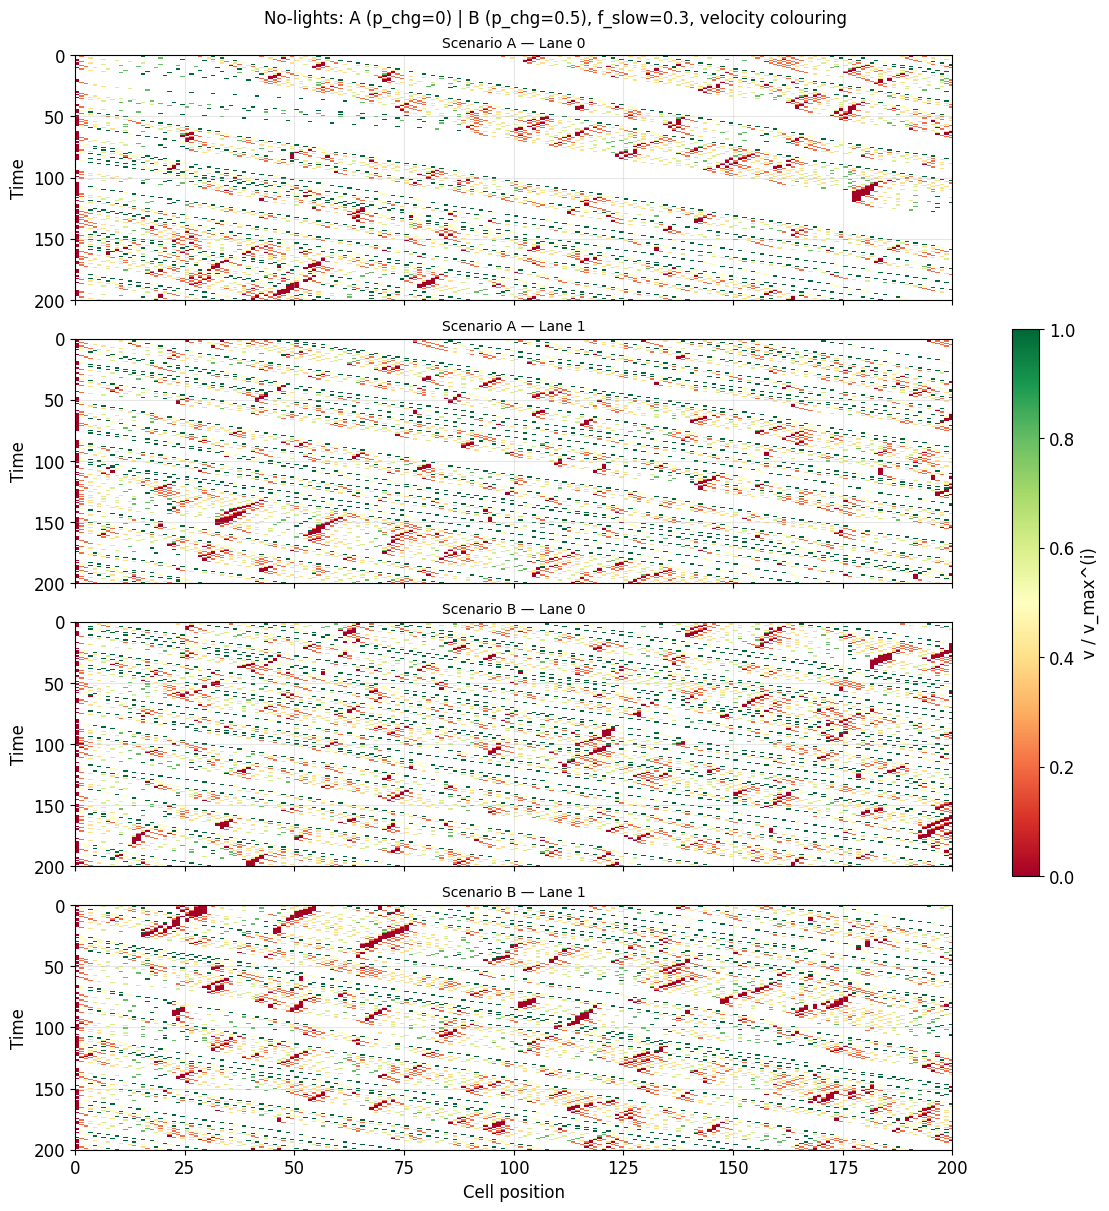

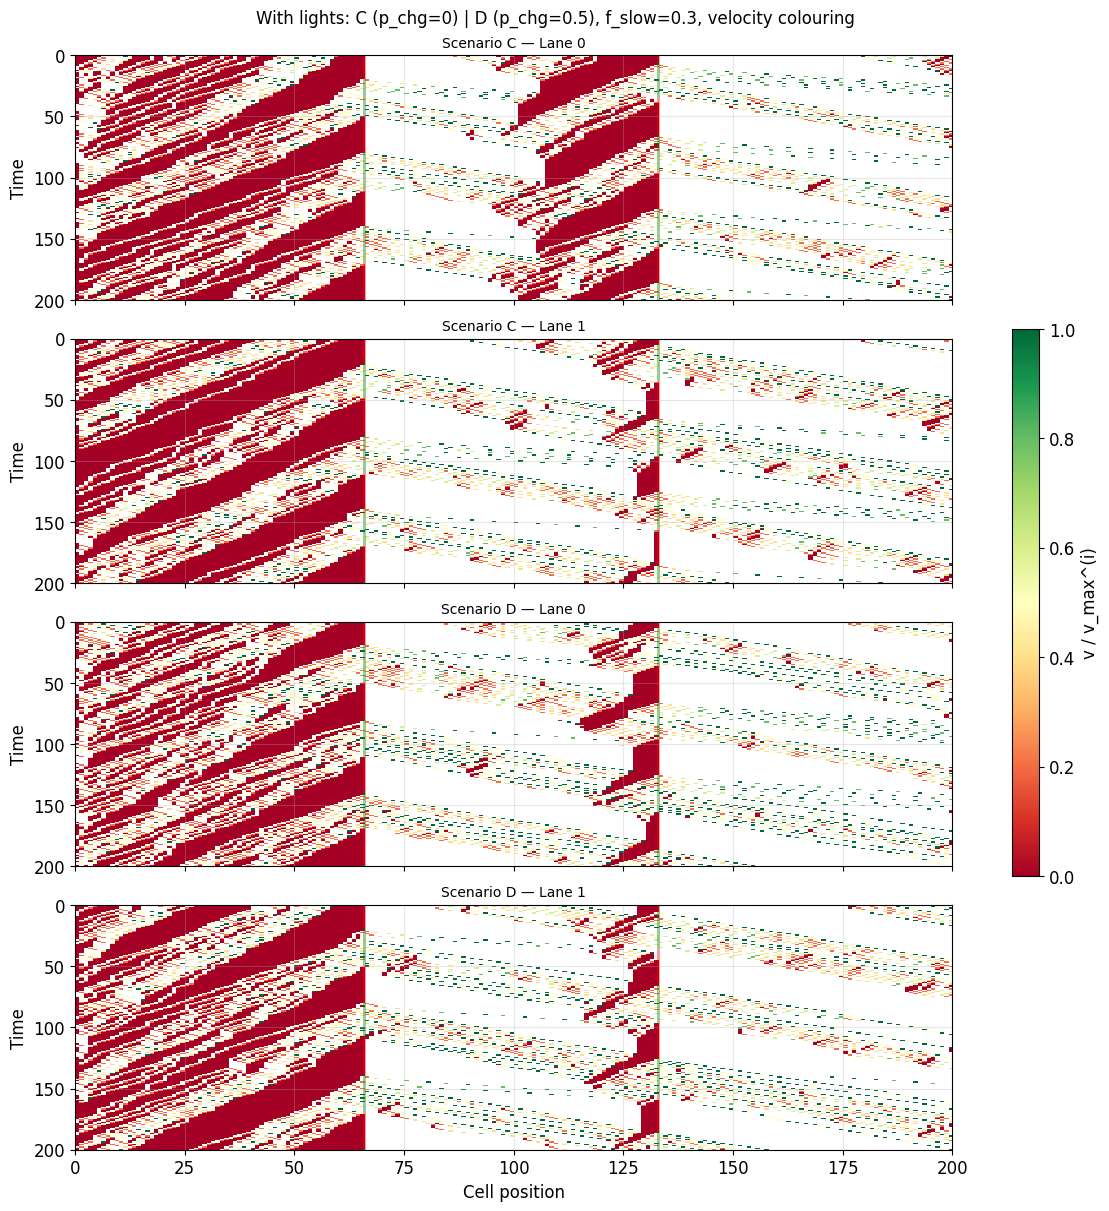

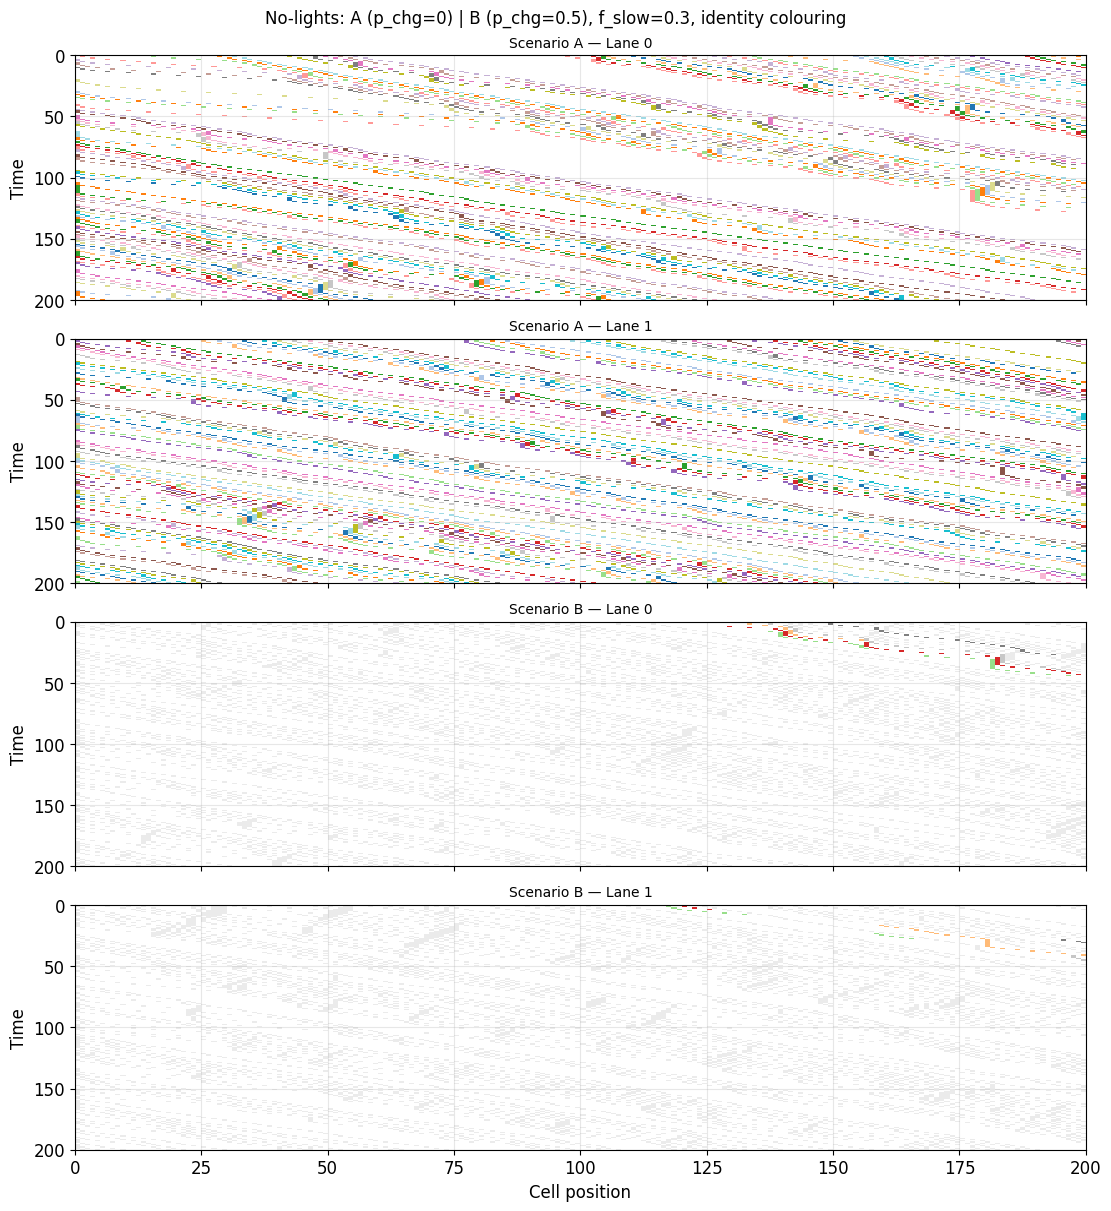

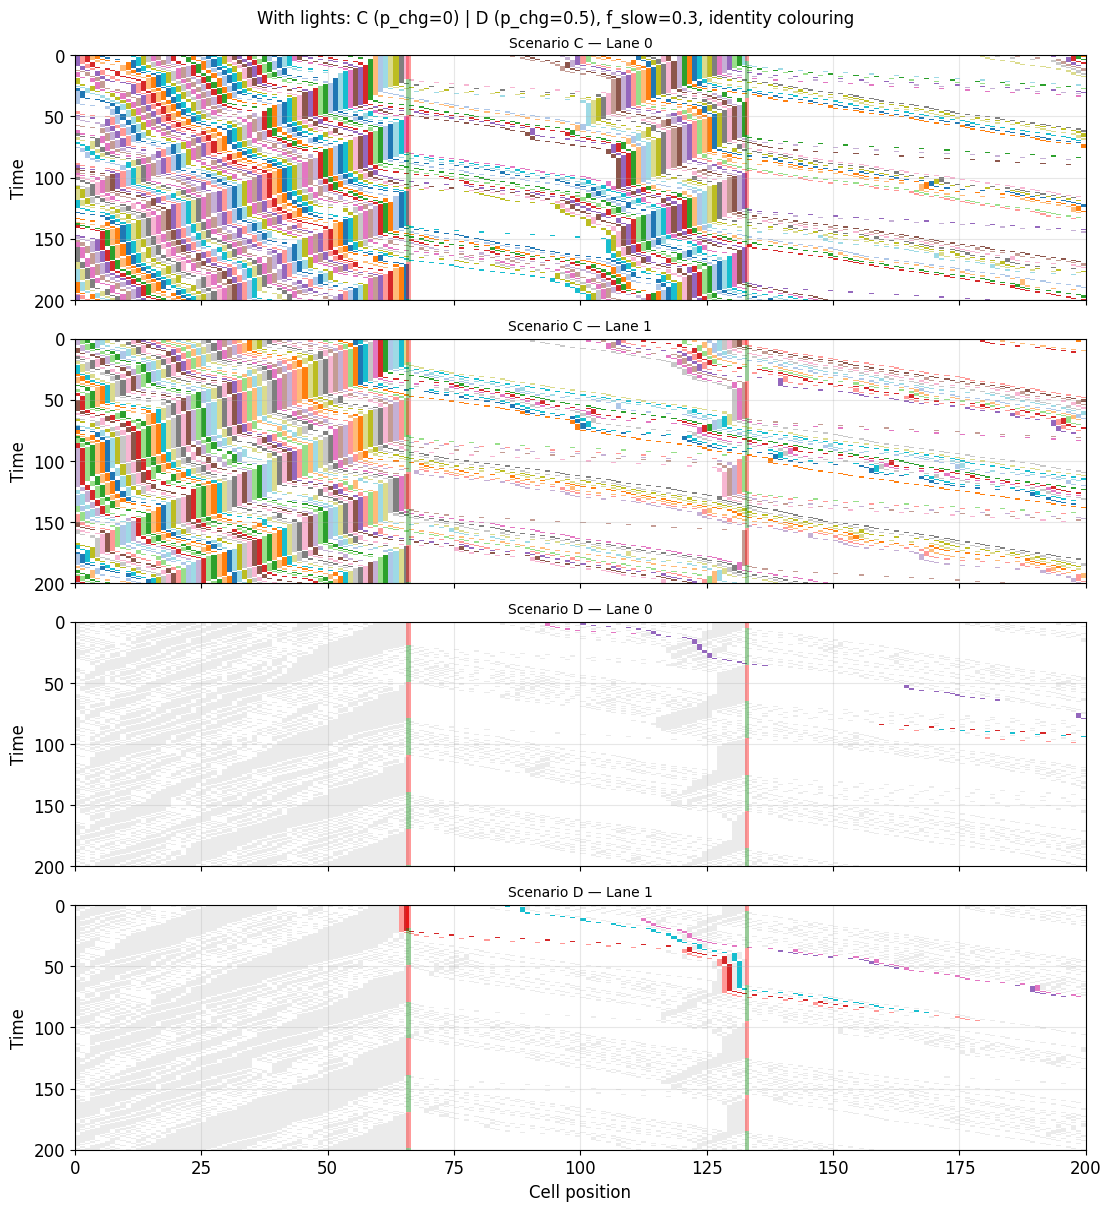

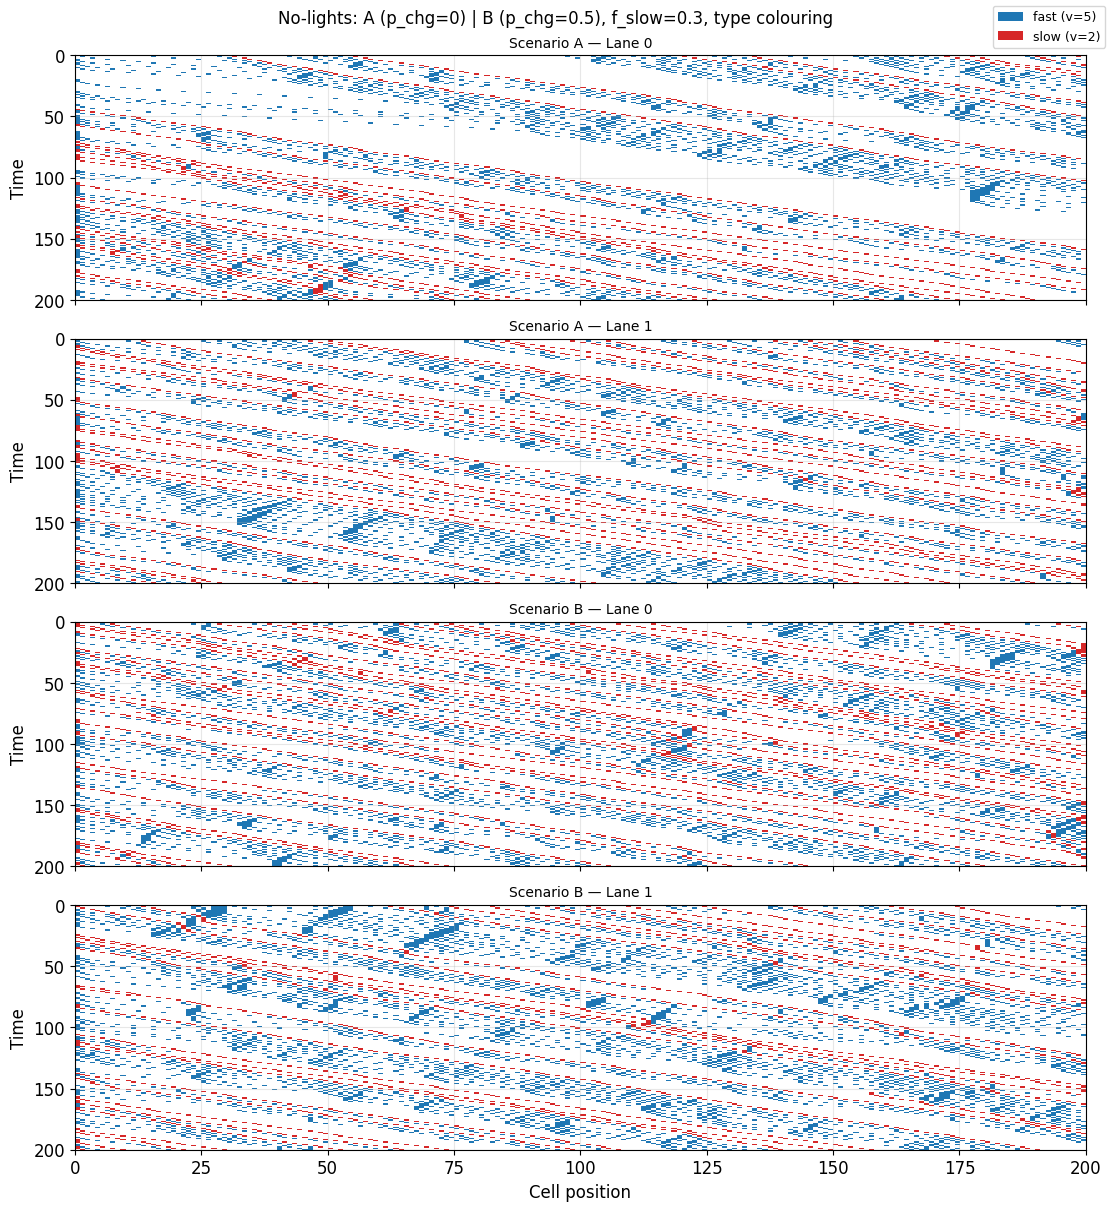

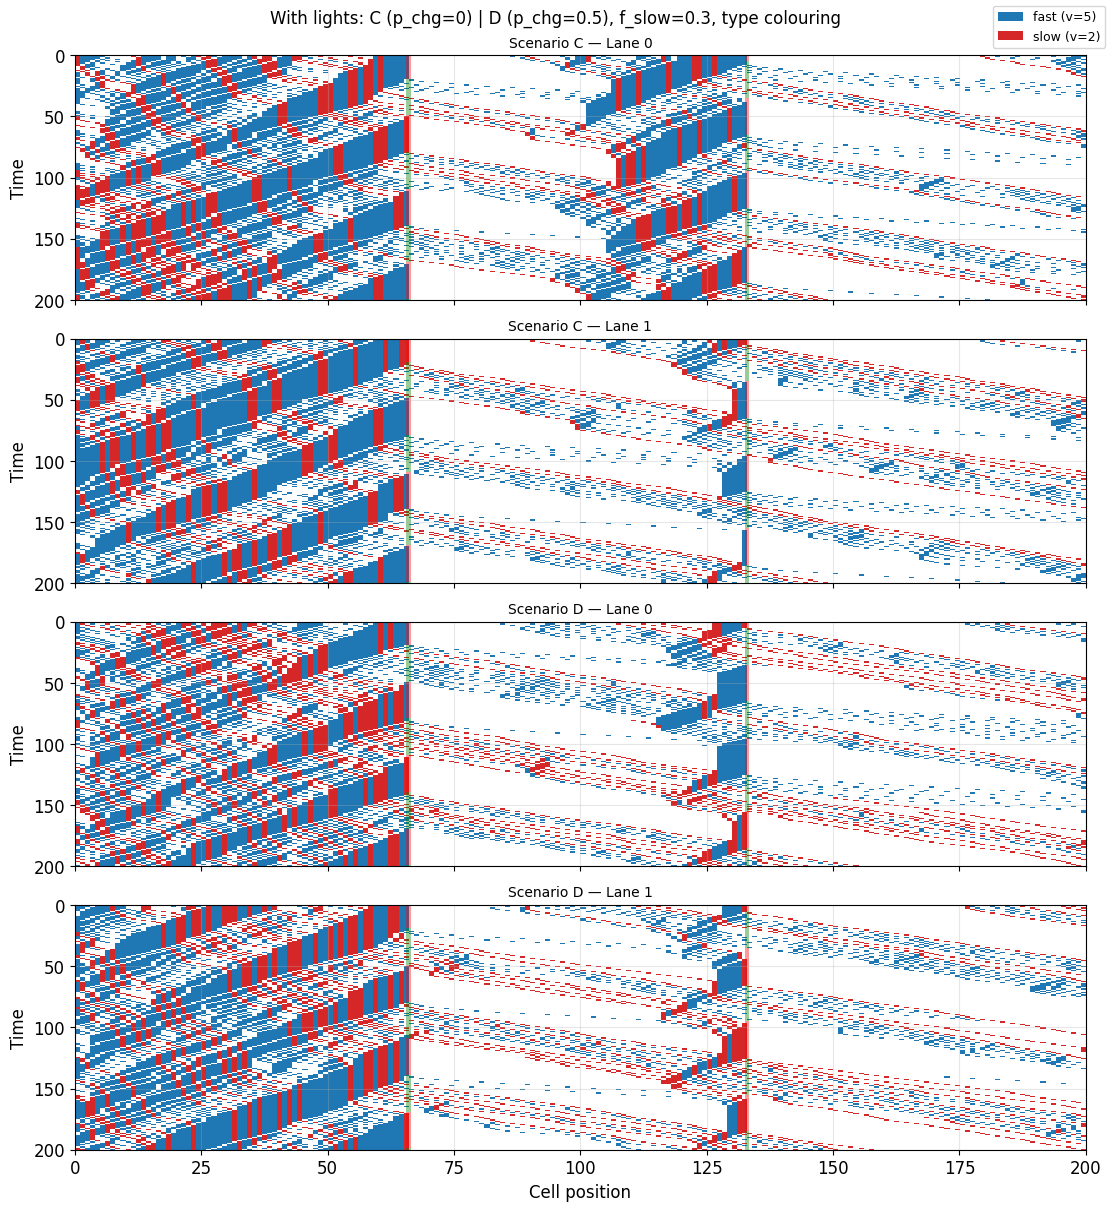

In [7]:
# Stack two scenarios side-by-side (or stacked) into a single figure
# per (colouring × light-condition). Each scenario contributes both lanes,
# so figure is 4 rows × 1 col (A/B lane0, A/B lane1, etc.).
from matplotlib.gridspec import GridSpec
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

def lane_panel_grid(scenario_keys, colouring, history_set, savepath, suptitle):
    n_scen = len(scenario_keys)
    fig, axes = plt.subplots(n_scen * 2, 1, figsize=(11, 3 * n_scen * 2),
                              sharex=True, constrained_layout=True)
    if colouring == 'velocity':
        cmap = plt.get_cmap('RdYlGn').copy()
        cmap.set_bad('white')
    elif colouring == 'type':
        cmap = ListedColormap(['white', '#1f77b4', '#d62728'])
        norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)
    last_im = None
    for si, label in enumerate(scenario_keys):
        h = history_set[label]
        T = h['velocity_history'].shape[0]
        for lane in (0, 1):
            ax = axes[si * 2 + lane]
            if colouring == 'velocity':
                v = h['velocity_history'][:, lane, :].astype(float)
                vm = h['v_max_history'][:, lane, :].astype(float)
                with np.errstate(divide='ignore', invalid='ignore'):
                    norm_arr = np.where(vm > 0, v / np.maximum(vm, 1), np.nan)
                norm_arr = np.where(h['velocity_history'][:, lane, :] < 0, np.nan, norm_arr)
                masked = np.ma.masked_invalid(norm_arr)
                last_im = ax.imshow(masked, aspect='auto', origin='upper',
                                     extent=[0, ST_L, T, 0], cmap=cmap,
                                     vmin=0, vmax=1, interpolation='nearest')
            elif colouring == 'identity':
                ids = h['car_id_history'][:, lane, :]
                rgba = np.ones(ids.shape + (4,))
                rgba[..., 3] = 0.0
                car_mask = ids >= 0
                base_cmap = plt.get_cmap('tab20')
                colours = base_cmap((ids % 20) / 19)
                rgba[car_mask] = colours[car_mask]
                # Highlight lane-changers in B and D
                if label in ('B', 'D'):
                    hl = set(find_lane_changers(h['car_id_history'], max_ids=5))
                    if hl:
                        hl_arr = np.isin(ids, list(hl))
                        non_hl = car_mask & ~hl_arr
                        rgba[non_hl] = (0.85, 0.85, 0.85, 0.5)
                ax.imshow(rgba, aspect='auto', origin='upper',
                           extent=[0, ST_L, T, 0], interpolation='nearest')
            elif colouring == 'type':
                vm = h['v_max_history'][:, lane, :]
                coded = np.zeros_like(vm)
                coded[vm == V_FAST] = 1
                coded[vm == V_SLOW] = 2
                ax.imshow(coded, aspect='auto', origin='upper',
                           extent=[0, ST_L, T, 0], cmap=cmap, norm=norm,
                           interpolation='nearest')
            ax.set_title(f'Scenario {label} — Lane {lane}', fontsize=10)
            ax.set_ylabel('Time')
            # Light overlay if present
            if 'light_state_history' in h:
                for li, pos in enumerate(h['light_pos']):
                    col = h['light_state_history'][:, li]
                    starts = [0] + [k for k in range(1, len(col))
                                    if col[k] != col[k-1]] + [len(col)]
                    for k in range(len(starts) - 1):
                        s, e = starts[k], starts[k+1]
                        ax.fill_betweenx([s, e], pos - 0.4, pos + 0.4,
                                         color='red' if col[s] else 'green',
                                         alpha=0.4, linewidth=0)
    axes[-1].set_xlabel('Cell position')
    if colouring == 'velocity':
        fig.colorbar(last_im, ax=axes, shrink=0.5, label='v / v_max^(i)')
    elif colouring == 'type':
        fig.legend(handles=[Patch(facecolor='#1f77b4', label=f'fast (v={V_FAST})'),
                             Patch(facecolor='#d62728', label=f'slow (v={V_SLOW})')],
                    loc='upper right', fontsize=9)
    fig.suptitle(suptitle, fontsize=12)
    fig.savefig(savepath)
    plt.show()

for colouring in ('velocity', 'identity', 'type'):
    lane_panel_grid(['A', 'B'], colouring, histories,
                     f'{FIGURES_DIR}/05_st_{colouring}_no_lights.png',
                     f'No-lights: A (p_chg=0) | B (p_chg=0.5), '
                     f'f_slow={ST_F_SLOW}, {colouring} colouring')
    lane_panel_grid(['C', 'D'], colouring, histories,
                     f'{FIGURES_DIR}/05_st_{colouring}_with_lights.png',
                     f'With lights: C (p_chg=0) | D (p_chg=0.5), '
                     f'f_slow={ST_F_SLOW}, {colouring} colouring')


## Summary

Slow vehicles drag flow down monotonically with `f_slow`. Lane-changing partially recovers the loss; the recovery fraction (Figure 05.B) is highest at intermediate `f_slow` and saturates by `p_chg ≈ 0.3`. The space-time figures show why: at `p_chg=0` slow cars lock down both lanes (visible as platoons of trapped fast cars). With `p_chg=0.5`, fast cars route around slow ones — visible as identity-coloured diagonal traces switching panels.